In [ ]:
#CNN

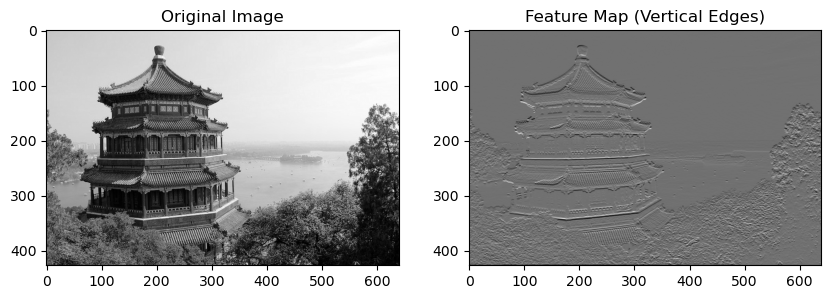

In [3]:
import tensorflow as tf
import matplotlib.pyplot as plt
from sklearn.datasets import load_sample_image

# Load and preprocess
china = load_sample_image("china.jpg") / 255
image = tf.image.rgb_to_grayscale(china)
image = tf.cast(image, tf.float32)  # Ensure float32
image = tf.expand_dims(image, axis=0)

# Vertical edge kernel (Sobel)
vertical_edge_kernel = tf.constant([
    [-1, -2, -1],
    [0, 0, 0],
    [1, 2, 1]
], dtype=tf.float32)

kernel = tf.reshape(vertical_edge_kernel, [3, 3, 1, 1])

# Convolution
feature_map = tf.nn.conv2d(image, kernel, strides=1, padding="SAME")

# Display
plt.figure(figsize=(10, 5))
plt.subplot(1, 2, 1)
plt.imshow(image[0, :, :, 0], cmap='gray')
plt.title("Original Image")
plt.axis('on')

plt.subplot(1, 2, 2)
plt.imshow(feature_map[0, :, :, 0], cmap='gray')
plt.title("Feature Map (Vertical Edges)")
plt.axis('on')
plt.show()


In [ ]:
# CONV-2D - Layer

In [3]:
import tensorflow as tf
from tensorflow import keras

input_tensor = tf.random.normal([1, 28, 28, 1])


conv_layer = keras.layers.Conv2D(filters=32, kernel_size=3, padding='same', activation='relu')


output_tensor = conv_layer(input_tensor)

print("Input Shape:", input_tensor.shape)
print("Output Shape:", output_tensor.shape)



Input Shape: (1, 28, 28, 1)
Output Shape: (1, 28, 28, 32)


In [4]:
#MaxPooling2D Layer

In [5]:

pool_layer = keras.layers.MaxPooling2D(pool_size=2)


pooled_output = pool_layer(output_tensor)

print("Shape before pooling:", output_tensor.shape)
print("Shape after pooling:", pooled_output.shape)



Shape before pooling: (1, 28, 28, 32)
Shape after pooling: (1, 14, 14, 32)


In [6]:
keras.layers.Conv2D(filters=32, kernel_size=3, strides=1, padding='same', activation='relu')

<Conv2D name=conv2d_1, built=False>

In [7]:
#Building CNN - CIFAR-10 Dataset

In [8]:
import tensorflow as tf
from tensorflow import keras


(X_train_full, y_train_full), (X_test, y_test) = keras.datasets.cifar10.load_data()



In [9]:

X_train = X_train_full.astype('float32') / 255.0
X_test = X_test.astype('float32') / 255.0


y_train = keras.utils.to_categorical(y_train_full, 10)
y_test = keras.utils.to_categorical(y_test, 10)

print("Shape of training images:", X_train.shape)



Shape of training images: (50000, 32, 32, 3)


Training Images Shape: (50000, 32, 32, 3)
Training Labels Shape: (50000, 1)

First Image Shape: (32, 32, 3)
First Image Label: 6
Class Name: Frog


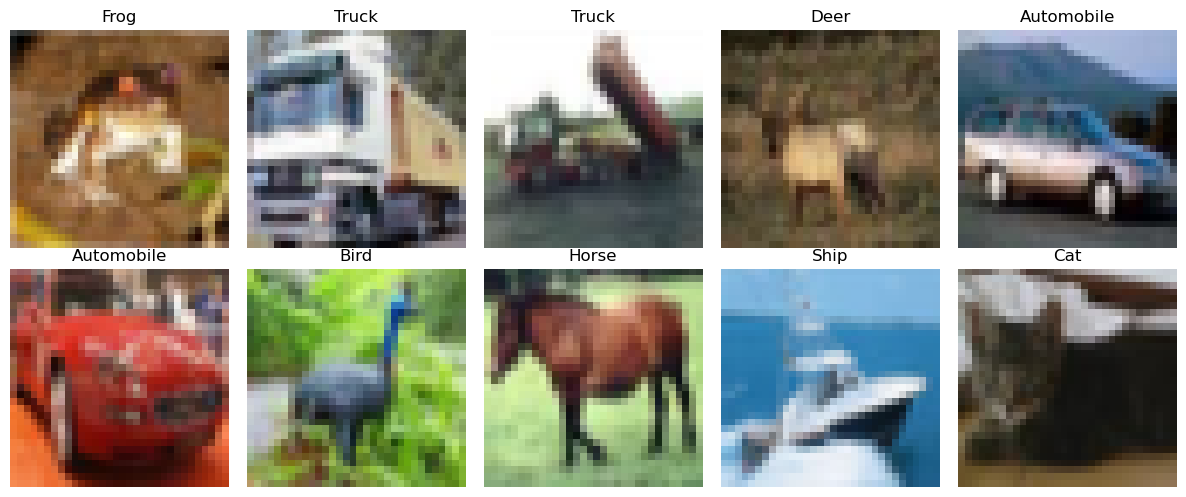

In [16]:
import tensorflow as tf
from tensorflow import keras
import matplotlib.pyplot as plt

# Load CIFAR-10 dataset
(X_train, y_train), (X_test, y_test) = keras.datasets.cifar10.load_data()

# Class names
class_names = [
    'Airplane',
    'Automobile',
    'Bird',
    'Cat',
    'Deer',
    'Dog',
    'Frog',
    'Horse',
    'Ship',
    'Truck'
]

# Print dataset information
print("Training Images Shape:", X_train.shape)
print("Training Labels Shape:", y_train.shape)

print("\nFirst Image Shape:", X_train[0].shape)
print("First Image Label:", y_train[0][0])
print("Class Name:", class_names[int(y_train[0][0])])

# Display first 10 images
plt.figure(figsize=(12, 5))

for i in range(10):
    plt.subplot(2, 5, i + 1)
    plt.imshow(X_train[i])
    plt.title(class_names[int(y_train[i][0])])
    plt.axis('off')

plt.tight_layout()
plt.show()


In [14]:
#Model

In [15]:
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import layers



model = keras.Sequential([
    
    layers.Conv2D(filters=32, kernel_size=3, activation='relu', input_shape=(32, 32, 3)),
    layers.MaxPooling2D(pool_size=2),
    
    layers.Conv2D(filters=64, kernel_size=3, activation='relu'),
    layers.MaxPooling2D(pool_size=2),

    
    layers.Flatten(),
    
   
    layers.Dense(64, activation='relu'),
    
   
    layers.Dense(10, activation='softmax')
])


model.compile(optimizer='adam',
              loss='categorical_crossentropy',
              metrics=['accuracy'])


model.summary()


Model: "sequential_1"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d_4 (Conv2D)               │ (None, 30, 30, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_3 (MaxPooling2D)  │ (None, 15, 15, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_5 (Conv2D)               │ (None, 13, 13, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_4 (MaxPooling2D)  │ (None, 6, 6, 64)       │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten_1 (Flatten)             │ (None, 2304)           │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_2 (Dense)                 │ (None, 64)             │       147,520 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_3 (Dense)                 │ (None, 10)             │           650 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 167,562 (654.54 KB)

 Trainable params: 167,562 (654.54 KB)

 Non-trainable params: 0 (0.00 B)

In [16]:
#Train

In [17]:

print("Starting CNN training...")
history = model.fit(
    X_train, 
    y_train, 
    epochs=20, 
    batch_size=64,
    validation_data=(X_test, y_test)
)
print("Training finished.")


Starting CNN training...
Epoch 1/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 36s 42ms/step - accuracy: 0.4443 - loss: 1.5431 - val_accuracy: 0.5635 - val_loss: 1.2486
Epoch 2/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 37s 37ms/step - accuracy: 0.5877 - loss: 1.1753 - val_accuracy: 0.6073 - val_loss: 1.1123
Epoch 3/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6376 - loss: 1.0435 - val_accuracy: 0.6434 - val_loss: 1.0247
Epoch 4/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 29s 37ms/step - accuracy: 0.6632 - loss: 0.9725 - val_accuracy: 0.6565 - val_loss: 0.9911
Epoch 5/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 41s 52ms/step - accuracy: 0.6828 - loss: 0.9128 - val_accuracy: 0.6671 - val_loss: 0.9693
Epoch 6/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 38s 48ms/step - accuracy: 0.6981 - loss: 0.8664 - val_accuracy: 0.6756 - val_loss: 0.9428
Epoch 7/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 32s 40ms/step - accuracy: 0.7146 - loss: 0.8260 - val_accuracy: 0.6844 - val_loss: 0.9212
Epoch 8/20
782/782 ━━━━━━━━━━━━━━━━━━━━ 42s 41ms/step - accuracy:

In [18]:
#Analyze the curves

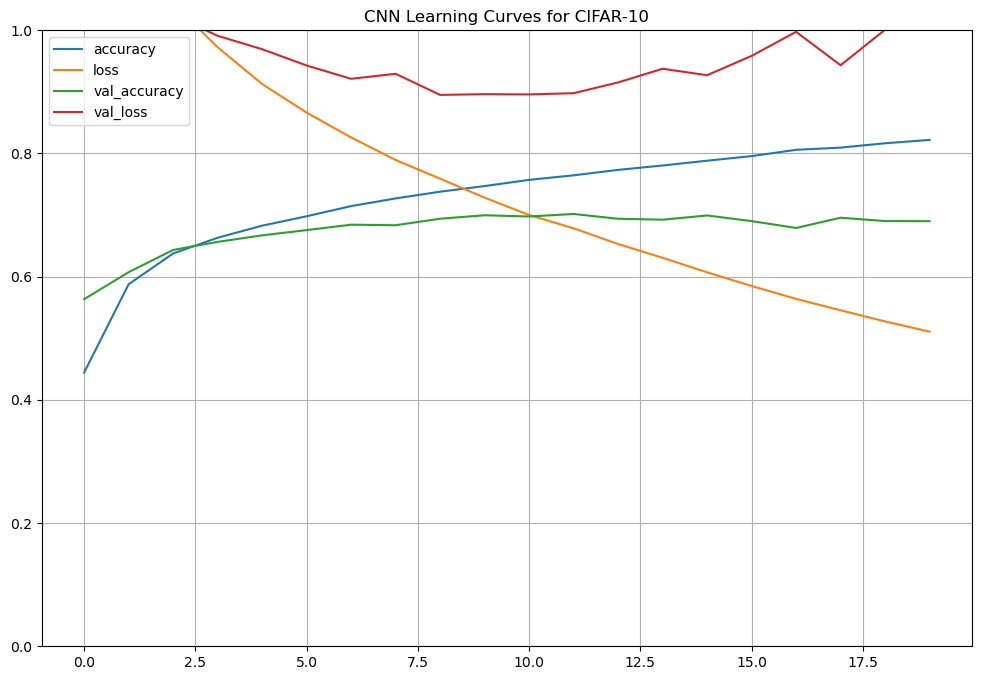

In [19]:
import pandas as pd
import matplotlib.pyplot as plt

history_df = pd.DataFrame(history.history)
history_df.plot(figsize=(12, 8), grid=True, title="CNN Learning Curves for CIFAR-10", ylim=(0,1))
plt.show()


In [20]:
#Evaluate the CNN performance

In [21]:
from sklearn.metrics import classification_report, confusion_matrix
import numpy as np

# Get final loss and accuracy on the test set
loss, accuracy = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {accuracy * 100:.2f}%")

# Get predictions to generate detailed reports
y_pred_probs = model.predict(X_test)
y_pred = np.argmax(y_pred_probs, axis=1)
y_true = np.argmax(y_test, axis=1)

# Classification Report
class_names = ['airplane', 'automobile', 'bird', 'cat', 'deer', 'dog', 'frog', 'horse', 'ship', 'truck']
print("\n--- Classification Report ---\n")
print(classification_report(y_true, y_pred, target_names=class_names))


Final Test Accuracy: 69.01%
313/313 ━━━━━━━━━━━━━━━━━━━━ 3s 9ms/step

--- Classification Report ---

              precision    recall  f1-score   support

    airplane       0.75      0.70      0.72      1000
  automobile       0.79      0.84      0.82      1000
        bird       0.66      0.53      0.58      1000
         cat       0.49      0.54      0.51      1000
        deer       0.63      0.59      0.61      1000
         dog       0.62      0.59      0.60      1000
        frog       0.82      0.69      0.75      1000
       horse       0.62      0.83      0.71      1000
        ship       0.82      0.80      0.81      1000
       truck       0.76      0.78      0.77      1000

    accuracy                           0.69     10000
   macro avg       0.70      0.69      0.69     10000
weighted avg       0.70      0.69      0.69     10000

